# Taller 1 — Notebook 01: Entendimiento inicial de datos

**MINE-4101: Ciencia de Datos Aplicada · Supervisión de contratación pública de bienes**

**Integrantes:** _(completar nombres)_

---

## Objetivo del notebook

Este notebook cubre el **Entregable 1 (20%)**: entendimiento inicial del dataset de contratos de
bienes de SECOP II (2019–2025). Aquí:

1. Reportamos **dimensiones** y **tipos de datos**.
2. Seleccionamos el **top-5 de atributos** más relevantes para el análisis y describimos su
   comportamiento (**análisis univariado**).
3. Establecemos y **justificamos el periodo** apropiado para el análisis.
4. Documentamos los **problemas de calidad de datos** detectados y cómo decidimos tratarlos.

> **Orden de ejecución del proyecto:** `01_entendimiento` → `02_limpieza` → `03_analisis`.
> Este notebook es exploratorio y **no modifica** el dataset; las correcciones se aplican en `02_limpieza`.


In [1]:
# --- Configuración e imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

RUTA_DATOS = '../data/raw/secop_bienes.parquet'
RUTA_FIGS = '../figs'


In [2]:
# --- Carga de datos ---
df = pd.read_parquet(RUTA_DATOS)
print(f'Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head(3)


Dimensiones del dataset: 196,391 filas x 36 columnas


,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,codigo_de_categoria_principal,objeto_del_contrato,fecha_de_firma,fecha_de_inicio_del_contrato,fecha_de_fin_del_contrato,duraci_n_del_contrato,condiciones_de_entrega,proveedor_adjudicado,documento_proveedor,es_pyme,es_grupo,g_nero_representante_legal,nacionalidad_representante_legal,valor_del_contrato,valor_pagado,valor_facturado,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidaci_n,obligaci_n_ambiental,urlproceso
0,CO1.PCCNTR.1000001,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Distrito Capital de Bogotá,No Definido,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,V1.50161509,Contratar a monto agotable por el sistema de p...,2019-06-19,2019-06-18,2019-12-31,No definido,Como acordado previamente,INDUSTRIAS GUERRERO Y COMPAÑIA S.A.S.,830130048,Si,No,No Definido,CO,"17,897,916.00",17896237,17896237,1679,0,No Definido,Si,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
1,CO1.PCCNTR.1000507,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Suministros,Selección Abreviada de Menor Cuantía,V1.50131612,SUMINISTRO DE HUEVOS CON DESTINO A LOS COMEDOR...,2019-06-23,2019-06-13,2019-11-29,Dia(s),Transporte incluido,Distribuidora Antioqueña AM,21788564,Si,No,Mujer,CO,"390,000,000.00",389999685,389999685,315,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
2,CO1.PCCNTR.1000901,FUERZA AEROESPACIAL COLOMBIANA,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,V1.53102701,ADQUISICIÓN DE PRESILLAS BORDADAS AZULES EN CA...,2019-06-18,2019-06-24,2019-09-30,No definido,DAP - Entregado en un punto (lugar de destino ...,FANNY JANETH GUTIERREZ PRIETO,20484821,No,No,Mujer,CO,"11,970,000.00",11970000,11970000,0,0,No Definido,Si,Distribuido,Funcionamiento,terminado,No,No,{'url': 'https://community.secop.gov.co/Public...


## 1. Dimensiones y tipos de datos

El dataset contiene contratos de bienes (compraventa y suministros) firmados por entidades públicas
colombianas entre 2019 y 2025. Revisamos la estructura general.


In [3]:
# Resumen de columnas: tipo, no-nulos y % de nulos
resumen = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'no_nulos': df.notna().sum(),
    'nulos': df.isna().sum(),
    'pct_nulos': (df.isna().mean() * 100).round(2),
    'n_unicos': df.nunique(),
})
resumen.sort_values('pct_nulos', ascending=False)


,tipo,no_nulos,nulos,pct_nulos,n_unicos
fecha_de_inicio_del_contrato,datetime64[us],193951,2440,1.24,2796
id_contrato,object,196391,0,0.00,196391
es_pyme,object,196391,0,0.00,2
g_nero_representante_legal,object,196391,0,0.00,4
nacionalidad_representante_legal,object,196391,0,0.00,30
valor_del_contrato,float64,196391,0,0.00,140287
valor_pagado,int64,196391,0,0.00,77582
valor_facturado,int64,196391,0,0.00,90662
valor_pendiente_de_pago,int64,196391,0,0.00,102172
dias_adicionados,int64,196391,0,0.00,380


In [4]:
# Conteo de columnas por tipo de dato
tipos = df.dtypes.astype(str).value_counts()
print('Columnas por tipo de dato:')
print(tipos.to_string())
print()
# Clasificación funcional de variables
numericas = df.select_dtypes(include=[np.number]).columns.tolist()
fechas = df.select_dtypes(include=['datetime']).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()
print(f'Numéricas ({len(numericas)}): {numericas}')
print(f'Fechas ({len(fechas)}): {fechas}')
print(f'Texto/categóricas ({len(categoricas)}): {len(categoricas)} columnas')


Columnas por tipo de dato:
object            28
int64              4
datetime64[us]     3
float64            1

Numéricas (5): ['valor_del_contrato', 'valor_pagado', 'valor_facturado', 'valor_pendiente_de_pago', 'dias_adicionados']
Fechas (3): ['fecha_de_firma', 'fecha_de_inicio_del_contrato', 'fecha_de_fin_del_contrato']
Texto/categóricas (28): 28 columnas


**Observaciones de tipos:**

- La mayoría de columnas son de **texto** (categóricas o identificadores/URLs).
- Hay 3 columnas de **fecha** (`fecha_de_firma`, `fecha_de_inicio_del_contrato`, `fecha_de_fin_del_contrato`).
- Las **numéricas** son los valores monetarios (`valor_del_contrato`, `valor_pagado`, `valor_facturado`,
  `valor_pendiente_de_pago`) y `dias_adicionados`.
- `duraci_n_del_contrato` viene como **texto** ("245 Dia(s)", "5 Mes(es)", "No definido") — deberá parsearse
  en la etapa de limpieza.
- Los nulos son bajos: el máximo es `fecha_de_inicio_del_contrato` (~1,2%).


## 2. Top-5 de atributos y análisis univariado

El enunciado nos da una pista de por dónde mirar: valor, modalidad, sector, tipo de entidad y destino del gasto.
Con ese criterio de negocio —qué características, conocidas al firmar, podrían anticipar un problema— elegimos
estos 5 atributos para el análisis univariado (la justificación es *a priori*; más adelante, en `03`, veremos
cuáles terminan pesando más):

| # | Atributo | Por qué lo elegimos |
|---|----------|---------------------|
| 1 | `valor_del_contrato` | Es la magnitud del riesgo en plata; el enunciado lo pone primero |
| 2 | `sector` | Distintos sectores compran cosas muy distintas y con procesos distintos |
| 3 | `modalidad_de_contratacion` | Define cuánta competencia y control tuvo el proceso |
| 4 | `tipo_de_contrato` | Comprar de una vez (compraventa) no es lo mismo que ir surtiendo (suministro) |
| 5 | `dias_adicionados` | Es, literalmente, una de las desviaciones que queremos entender |

Este top-5 es el foco del univariado de este entregable; el análisis de `03` usa además `orden`, `destino_gasto`,
`liquidaci_n`, `valor_facturado` y `estado_contrato`. El rol de cada variable está en el **inventario (2.6)**, y
`estado_contrato` lo vemos en la sección 3, que es donde nos ayuda a decidir el periodo.


### 2.1 `valor_del_contrato` (numérica)

In [5]:
vc = df['valor_del_contrato']
print('Estadísticos de valor_del_contrato (COP):')
print(vc.describe([.01, .05, .25, .5, .75, .95, .99]).to_string())
print()
print(f'Contratos con valor <= 0: {(vc <= 0).sum():,}')
print(f'Máximo: {vc.max():,.0f}  (valor implausible -> outlier de calidad)')
print(f'Mediana: {vc.median():,.0f}   Media: {vc.mean():,.0f}  (media >> mediana: fuerte sesgo a la derecha)')


Estadísticos de valor_del_contrato (COP):
count                  196,391.00
mean            65,824,255,027.86
std         29,015,352,967,837.04
min                          0.00
1%                     701,068.00
5%                   2,309,772.50
25%                 12,021,214.00
50%                 33,600,000.00
75%                100,000,000.00
95%                800,000,000.00
99%              4,118,481,942.98
max     12,858,450,316,000,000.00

Contratos con valor <= 0: 188
Máximo: 12,858,450,316,000,000  (valor implausible -> outlier de calidad)
Mediana: 33,600,000   Media: 65,824,255,028  (media >> mediana: fuerte sesgo a la derecha)


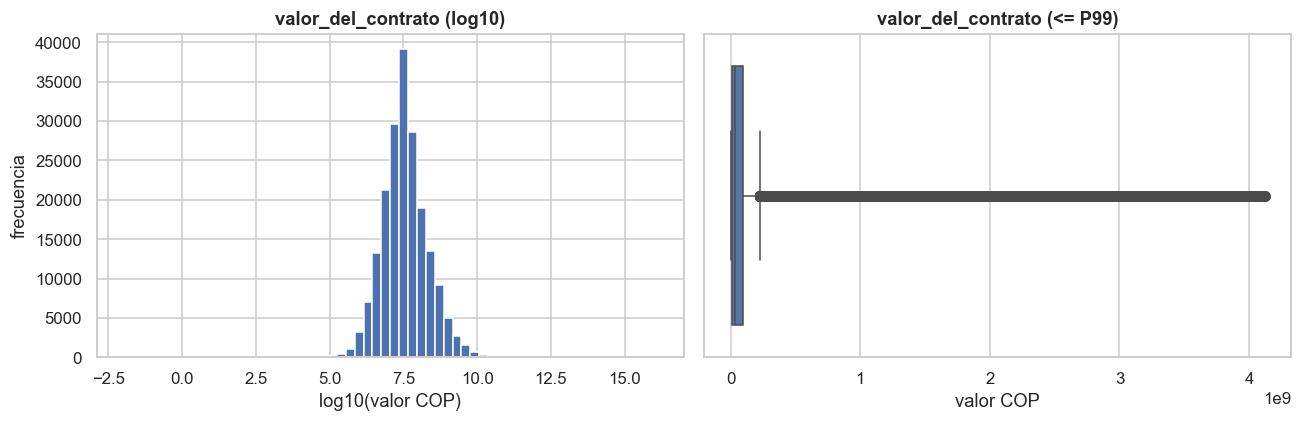

In [6]:
# Distribución en escala log (por el fuerte sesgo). Se excluyen valores <= 0 solo para graficar.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pos = vc[vc > 0]
axes[0].hist(np.log10(pos), bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_title('valor_del_contrato (log10)')
axes[0].set_xlabel('log10(valor COP)'); axes[0].set_ylabel('frecuencia')

# Boxplot recortado al percentil 99 para ver la caja
p99 = pos.quantile(0.99)
sns.boxplot(x=pos[pos <= p99], ax=axes[1], color='#4C72B0')
axes[1].set_title('valor_del_contrato (<= P99)')
axes[1].set_xlabel('valor COP')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/01_valor_contrato.png', bbox_inches='tight'); plt.show()


El valor de los contratos está **muy desbalanceado hacia arriba**: la mitad de los contratos vale menos de
~33,6 millones, pero el promedio se dispara a ~66 mil millones porque unos pocos son gigantescos (y hay un máximo
imposible de ~1,3e16 COP, claramente un error). Dos consecuencias prácticas: para analizarlo conviene usar
**escala logarítmica**, y hay que **tratar los valores extremos** en la limpieza.


### 2.2 `sector` (categórica)

26 sectores distintos. Más frecuentes y menos frecuentes:
sector
Servicio Público                    37390
defensa                             34585
No aplica/No pertenece              24465
Salud y Protección Social           22037
Ley de Justicia                     20377
Trabajo                             14759
Educación Nacional                  10231
Ambiente y Desarrollo Sostenible     8109
   ...
sector
Información Estadística                          470
Relaciones Exteriores                            332
Inteligencia Estratégica y Contrainteligencia    100
No Definido                                        9


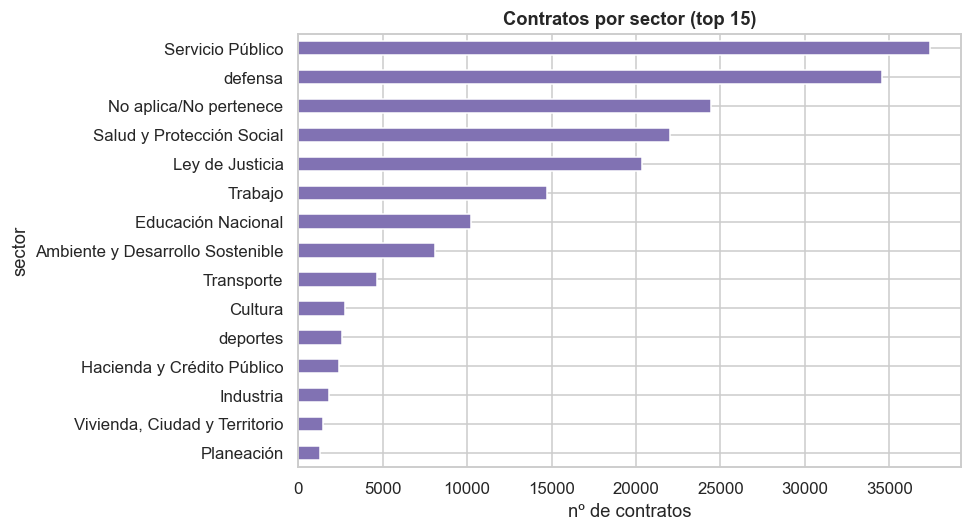

In [7]:
sec = df['sector'].value_counts()
print(f'{df["sector"].nunique()} sectores distintos. Más frecuentes y menos frecuentes:')
print(sec.head(8).to_string()); print('   ...'); print(sec.tail(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
sec.head(15).sort_values().plot(kind='barh', ax=ax, color='#8172B3')
ax.set_title('Contratos por sector (top 15)'); ax.set_xlabel('nº de contratos')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/01_sector.png', bbox_inches='tight'); plt.show()


Hay **26 sectores** distintos y la contratación se concentra en unos pocos. Como cada sector compra cosas
distintas y con dinámicas distintas, esperamos que sea una variable útil para el análisis (lo confirmaremos en
`03`). *(Un detalle de calidad: algunas etiquetas vienen en minúscula —p. ej. `defensa`—; lo tratamos en la
sección 4 y lo estandarizamos en `02`.)*


### 2.3 `modalidad_de_contratacion` (categórica)

modalidad_de_contratacion
Mínima cuantía                                                 117753
Selección abreviada subasta inversa                             32907
Contratación régimen especial                                   19250
Selección Abreviada de Menor Cuantía                             8822
Contratación régimen especial (con ofertas)                      6154
Contratación Directa (con ofertas)                               5001
Contratación directa                                             3938
Licitación pública                                               2330
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes       236

Modalidad dominante: Mínima cuantía (60.0% de los contratos)


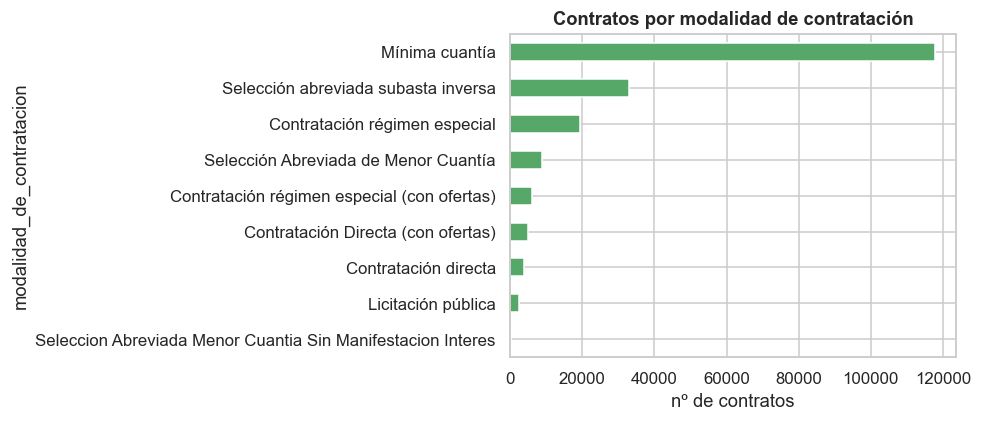

In [8]:
mod = df['modalidad_de_contratacion'].value_counts()
print(mod.to_string())
print(f'\nModalidad dominante: {mod.index[0]} ({mod.iloc[0]/len(df)*100:.1f}% de los contratos)')

fig, ax = plt.subplots(figsize=(9, 4))
mod.sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Contratos por modalidad de contratación')
ax.set_xlabel('nº de contratos')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/01_modalidad.png', bbox_inches='tight'); plt.show()


La gran mayoría de los contratos (~60%) se hace por **mínima cuantía**, y le sigue la **subasta inversa**.
O sea, la compra de bienes se apoya sobre todo en modalidades de montos chicos —lo cual cuadra con que la mitad
de los contratos valga poco.


### 2.4 `tipo_de_contrato` (categórica)

tipo_de_contrato
Suministros    106632
Compraventa     89759

Reparto: Suministros 54.3%  |  Compraventa 45.7%


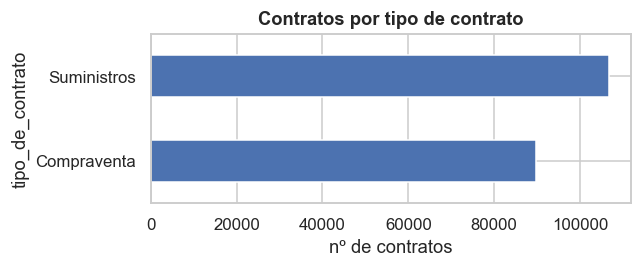

In [9]:
tc = df['tipo_de_contrato'].value_counts()
print(tc.to_string())
print(f'\nReparto: {tc.index[0]} {tc.iloc[0]/len(df)*100:.1f}%  |  {tc.index[1]} {tc.iloc[1]/len(df)*100:.1f}%')

fig, ax = plt.subplots(figsize=(6, 2.6))
tc.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Contratos por tipo de contrato'); ax.set_xlabel('nº de contratos')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/01_tipo_contrato.png', bbox_inches='tight'); plt.show()


Solo hay dos tipos, bastante parejos: **Suministros** (~54%) y **Compraventa** (~46%). La distinción
importa porque son formas distintas de comprar —de una sola vez vs. ir surtiendo—, y esperamos que se comporten
distinto frente a las desviaciones (lo veremos en `03`).


### 2.5 `dias_adicionados` (numérica — una de las desviaciones)

Estadísticos de dias_adicionados:
count   196,391.00
mean          5.11
std          40.66
min           0.00
50%           0.00
90%           0.00
95%          30.00
99%         122.00
max      14,276.00

Contratos con adición de plazo (>0): 18,671  (9.5%)
Máximo: 14,276 días (~39 años -> outlier implausible)


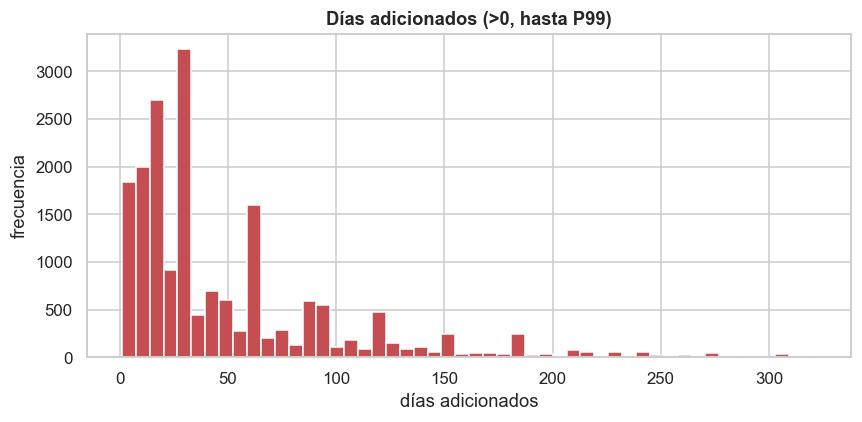

In [10]:
da = df['dias_adicionados']
print('Estadísticos de dias_adicionados:')
print(da.describe([.9, .95, .99]).to_string())
print()
print(f'Contratos con adición de plazo (>0): {(da > 0).sum():,}  ({(da > 0).mean()*100:.1f}%)')
print(f'Máximo: {da.max():,} días (~{da.max()/365:.0f} años -> outlier implausible)')

fig, ax = plt.subplots(figsize=(8, 4))
adic = da[(da > 0) & (da <= da[da > 0].quantile(0.99))]
ax.hist(adic, bins=50, color='#C44E52', edgecolor='white')
ax.set_title('Días adicionados (>0, hasta P99)')
ax.set_xlabel('días adicionados'); ax.set_ylabel('frecuencia')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/01_dias_adicionados.png', bbox_inches='tight'); plt.show()


Casi todos los contratos (~90%) **no** piden plazo extra: la variable está pegada al cero, con una cola
larga hacia la derecha. Ese ~9,5% que sí pide adición es justo la señal que nos interesa. El máximo (~14.276
días, casi 40 años) es un error y lo trataremos como outlier.


### 2.6 Inventario de variables usadas en el ejercicio

Para dar trazabilidad completa, este es el rol de cada variable a lo largo del ejercicio (limpieza, construcción
de banderas, análisis). El **top-5** anterior es el foco del univariado; el análisis usa además las siguientes:

| Variable | Rol en el ejercicio |
|----------|---------------------|
| `valor_del_contrato` | **Top-5** · predictor (3 desviaciones) · limpieza de outliers |
| `sector` | **Top-5** · predictor H4 (no-liquidación) · estandarización de casing |
| `modalidad_de_contratacion` | **Top-5** · predictor H2 (adición) |
| `tipo_de_contrato` | **Top-5** · predictor H3 (subejecución) |
| `dias_adicionados` | **Top-5** · define bandera `adicion_plazo` · tratamiento de outliers |
| `orden` | Predictor H4 (no-liquidación) |
| `destino_gasto` | Predictor secundario (H3/adición); segmentación Funcionamiento/Inversión |
| `es_pyme` | Predictor H5 (hipótesis nula) |
| `estado_contrato` | Filtro `ciclo_cerrado`; decisión de periodo (sección 3) |
| `liquidaci_n` | Define bandera `sin_liquidar` |
| `valor_facturado` | Define bandera `subejecucion` (ratio de ejecución) |
| `valor_pagado`, `valor_pendiente_de_pago` | Diagnóstico de calidad/consistencia (subreporte, identidad) |
| `fecha_de_firma` / `_inicio` / `_fin` | `anio_firma`, periodo, chequeos de consistencia temporal |
| `duraci_n_del_contrato` | Parseo a `duracion_dias` |
| `id_contrato` | Identificador (verificación de unicidad) |

**No se usan** (14 columnas): identificadores/URLs y texto libre (`nombre_entidad`, `objeto_del_contrato`,
`urlproceso`, `proveedor_adjudicado`, `documento_proveedor`, `codigo_de_categoria_principal`,
`condiciones_de_entrega`), atributos del representante legal (`g_nero_representante_legal`,
`nacionalidad_representante_legal`) y geografía/otros (`departamento`, `ciudad`, `rama`, `entidad_centralizada`,
`origen_de_los_recursos`). Se excluyen por ser identificadores, texto no estructurado o dimensiones fuera del
alcance de focalización de este análisis; podrían explorarse en trabajo futuro (p. ej. geografía).


## 3. Decisión del periodo de análisis (justificada)

El rango cubre 7 años y el enunciado advierte que **no todos son comparables**. La variable `estado_contrato`
—que define qué contratos tienen ciclo completable— es la clave de esta decisión, así que la analizamos aquí.


estado_contrato
terminado       54230
En ejecución    51441
Cerrado         46824
Modificado      34462
Aprobado         9211
Suspendido        153
cedido             43
Cancelado          26
Borrador            1


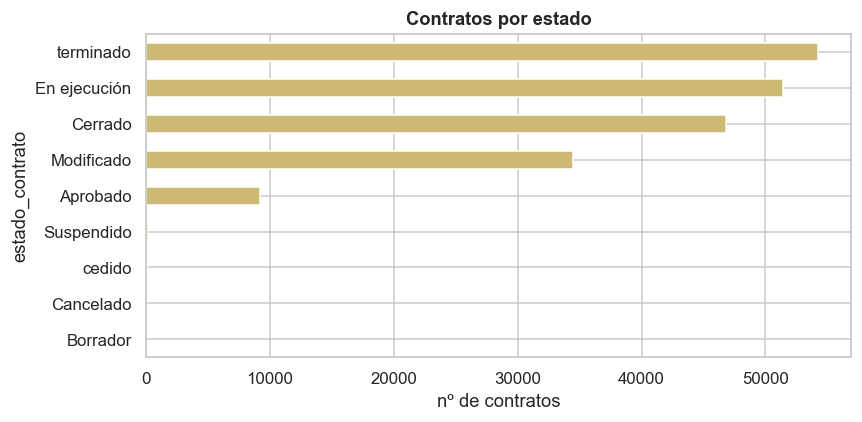

In [11]:
ec = df['estado_contrato'].value_counts()
print(ec.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ec.sort_values().plot(kind='barh', ax=ax, color='#CCB974')
ax.set_title('Contratos por estado')
ax.set_xlabel('nº de contratos')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/01_estado_contrato.png', bbox_inches='tight'); plt.show()


Los estados se reparten entre **terminado / En ejecución / Cerrado / Modificado**, con ~51k contratos aún
**En ejecución**. Esto es determinante: un contrato en ejecución todavía no ha ejecutado todo su presupuesto ni
se ha liquidado, así que **no es comparable** con uno cerrado para medir subejecución o no-liquidación.
Verificamos a continuación con datos cómo el año de firma y el estado condicionan la medición de las desviaciones.


In [12]:
# % de valor_pagado == 0 y % en ejecución, por año de firma
df_p = df.copy()
df_p['anio_firma'] = df_p['fecha_de_firma'].dt.year
tabla = df_p.groupby('anio_firma').agg(
    contratos=('id_contrato', 'size'),
    pct_pagado_cero=('valor_pagado', lambda s: (s == 0).mean() * 100),
    pct_en_ejecucion=('estado_contrato', lambda s: (s == 'En ejecución').mean() * 100),
    pct_terminado_cerrado=('estado_contrato', lambda s: s.isin(['terminado', 'Cerrado']).mean() * 100),
).round(1)
tabla


,contratos,pct_pagado_cero,pct_en_ejecucion,pct_terminado_cerrado
anio_firma,,,,
2019,16425,72.10,0.00,52.80
2020,20135,64.00,19.00,57.10
2021,24043,59.10,24.90,58.70
2022,28070,52.80,25.40,59.00
2023,32971,52.70,29.00,53.00
2024,34634,47.10,28.60,52.70
2025,40113,50.30,37.50,36.00


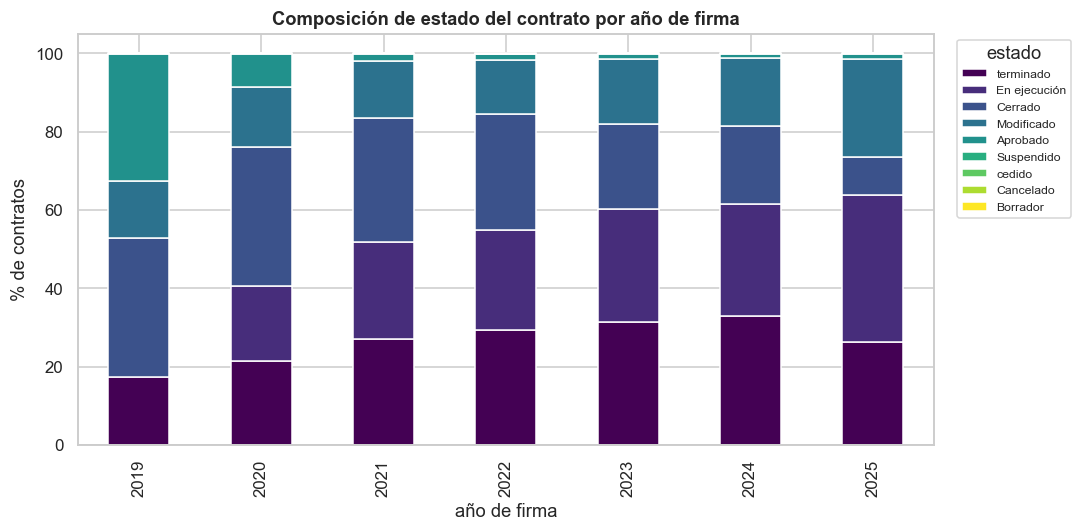

In [13]:
# Visual: estado del contrato por año de firma (proporción)
ct = pd.crosstab(df_p['anio_firma'], df_p['estado_contrato'], normalize='index') * 100
orden_estados = df['estado_contrato'].value_counts().index
ct = ct[[c for c in orden_estados if c in ct.columns]]
fig, ax = plt.subplots(figsize=(10, 5))
ct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
ax.set_title('Composición de estado del contrato por año de firma')
ax.set_ylabel('% de contratos'); ax.set_xlabel('año de firma')
ax.legend(title='estado', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/01_estado_por_anio.png', bbox_inches='tight'); plt.show()


### Qué periodo usamos (y por qué)

La tabla nos dice dos cosas:

- **Los contratos recientes todavía están "en veremos".** El % en ejecución sube con el año (de 0% en 2019 a
  ~37,5% en 2025) y el % ya cerrado cae en 2025 (~36%). Es decir, muchos de 2024–2025 siguen abiertos: si los
  metiéramos como si estuvieran terminados, parecería que "se desviaron" contratos que en realidad solo están en
  curso. Eso dañaría las medidas de subejecución y de no-liquidación.
- **Ojo con `valor_pagado`: viene muy incompleto.** El % de contratos con pagado en cero es alto en *todos* los
  años (52%–72%), y hasta mayor en los años viejos. Eso no es efecto del periodo, sino que el campo está
  **subreportado** en la fuente. Por eso en `03` no medimos la subejecución solo con `valor_pagado`: usamos
  también `valor_facturado` y nos quedamos con contratos ya cerrados.

**Lo que decidimos:** para las desviaciones que necesitan que el contrato haya cerrado (subejecución y
no-liquidación), nos quedamos con contratos de **ciclo ya mayormente cerrado** —en la práctica, **firmas hasta
2023**— y fijamos el corte exacto en `02`. Las **adiciones de plazo** sí se pueden ver antes de que cierre, así
que ahí podemos usar una ventana un poco más amplia. Lo del `valor_pagado` incompleto queda anotado como una
limitación de medición.


## 4. Calidad de datos: auditoría por dimensiones

Estos son datos administrativos reales. No basta con revisar nulos: auditamos las **cinco dimensiones**
estándar de calidad —**completitud, validez, consistencia entre campos, uniformidad/estandarización y
unicidad**— cuantificando cada problema. Los tratamientos se **implementan en `02_limpieza`**.


### 4.1 Completitud (valores faltantes)

In [14]:
nulos = df.isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print('Columnas con valores faltantes:')
print((pd.DataFrame({'nulos': nulos, 'pct': (nulos/len(df)*100).round(2)})).to_string() if len(nulos) else 'Sin nulos')
print(f'\nÚnica columna con faltantes relevantes: fecha_de_inicio_del_contrato (~1,2%).')


Columnas con valores faltantes:
                              nulos  pct
fecha_de_inicio_del_contrato   2440 1.24
documento_proveedor               4 0.00

Única columna con faltantes relevantes: fecha_de_inicio_del_contrato (~1,2%).


### 4.2 Validez (dominios y rangos permitidos)

In [15]:
val = []
val.append(('valor_del_contrato <= 0', (df['valor_del_contrato'] <= 0).sum()))
p999 = df['valor_del_contrato'].quantile(0.999)
val.append((f'valor_del_contrato > P99.9 ({p999:,.0f}) [outlier, máx ~1.3e16]', (df['valor_del_contrato'] > p999).sum()))
val.append(('dias_adicionados > 3 años [máx ~14.276 días]', (df['dias_adicionados'] > 365*3).sum()))
val.append(("duraci_n_del_contrato no numérica ('No definido'/vacía)",
            df['duraci_n_del_contrato'].astype(str).str.strip().isin(['No definido', 'Dia(s)', '']).sum()))
val.append(('fecha_de_fin anterior a 2019 (fuera de rango)', (df['fecha_de_fin_del_contrato'].dt.year < 2019).sum()))
val.append(('fecha_de_fin posterior a 2035 (implausible, máx 2065)', (df['fecha_de_fin_del_contrato'].dt.year > 2035).sum()))
qa_val = pd.DataFrame(val, columns=['problema_validez', 'n'])
qa_val['pct'] = (qa_val['n'] / len(df) * 100).round(2)
qa_val


,problema_validez,n,pct
0,valor_del_contrato <= 0,188,0.10
1,"valor_del_contrato > P99.9 (30,959,141,166) [o...",197,0.10
2,dias_adicionados > 3 años [máx ~14.276 días],1,0.00
3,duraci_n_del_contrato no numérica ('No definid...,20817,10.60
4,fecha_de_fin anterior a 2019 (fuera de rango),890,0.45
5,"fecha_de_fin posterior a 2035 (implausible, má...",7,0.00


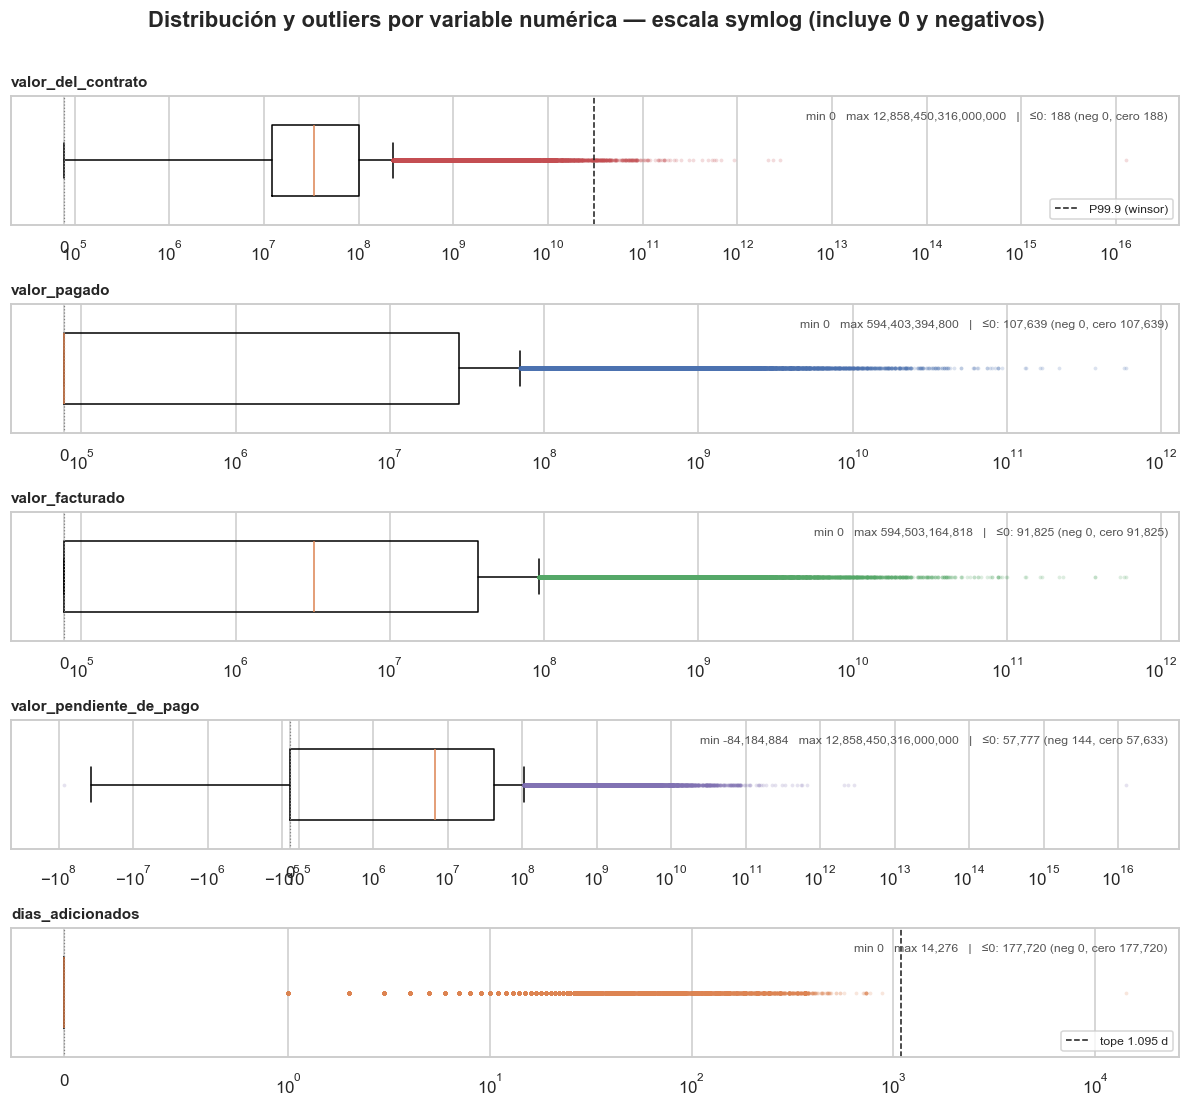

In [16]:
# Un boxplot POR variable numérica (escalas distintas) con escala symlog:
# symlog muestra el bulk, los outliers positivos extremos Y los valores <= 0 / negativos.
num_cols = ['valor_del_contrato', 'valor_pagado', 'valor_facturado', 'valor_pendiente_de_pago', 'dias_adicionados']
umbrales = {'valor_del_contrato': (df['valor_del_contrato'].quantile(0.999), 'P99.9 (winsor)'),
            'dias_adicionados': (365*3, 'tope 1.095 d')}
colores = ['#C44E52', '#4C72B0', '#55A868', '#8172B3', '#DD8452']

fig, axes = plt.subplots(len(num_cols), 1, figsize=(11, 2.0*len(num_cols)))
for ax, col, color in zip(axes, num_cols, colores):
    x = df[col].values
    ax.boxplot(x, vert=False, widths=0.55, showfliers=True,
               flierprops=dict(marker='o', markersize=2.5, alpha=0.20, markerfacecolor=color, markeredgecolor='none'))
    ax.set_xscale('symlog', linthresh=(1 if col == 'dias_adicionados' else 1e6))
    ax.axvline(0, color='gray', lw=0.8, ls=':')                      # marca el cero (frontera de negativos)
    if col in umbrales:
        thr, etiqueta = umbrales[col]
        ax.axvline(thr, color='k', lw=1, ls='--', label=etiqueta); ax.legend(loc='lower right', fontsize=8)
    n_neg = int((x < 0).sum()); n_cero = int((x == 0).sum())
    ax.set_yticks([]); ax.set_title(col, fontsize=10, loc='left', fontweight='bold')
    ax.annotate(f'min {x.min():,.0f}   max {x.max():,.0f}   |   ≤0: {n_neg + n_cero:,} (neg {n_neg:,}, cero {n_cero:,})',
                xy=(0.99, 0.82), xycoords='axes fraction', ha='right', fontsize=8, color='#555')
fig.suptitle('Distribución y outliers por variable numérica — escala symlog (incluye 0 y negativos)',
             fontweight='bold', y=1.005)
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/01_outliers_boxplot.png', bbox_inches='tight'); plt.show()


Ahora hay **un boxplot por variable numérica**, cada uno con su propia escala (las magnitudes difieren), y
en escala **symlog** para no ocultar los valores **≤ 0**: se ven tanto los outliers positivos extremos
(`valor_del_contrato` hasta ~1.3e16 COP; `dias_adicionados` ~14.276 d) como los del extremo bajo —el
`valor_pendiente_de_pago` **negativo** (mín ~−84M) y los contratos con valor **cero**—. La línea punteada gris
marca el cero (frontera de los negativos) y las líneas negras, los umbrales de tratamiento (winsorización P99.9
del valor y tope de 1.095 días) aplicados en `02`.


### 4.3 Consistencia entre campos (coherencia lógica)

In [17]:
con = []
# Coherencia temporal
con.append(('firma > inicio (firma posterior al inicio)', (df['fecha_de_firma'] > df['fecha_de_inicio_del_contrato']).sum()))
con.append(('firma > fin (termina antes de firmarse: imposible)', (df['fecha_de_firma'] > df['fecha_de_fin_del_contrato']).sum()))
con.append(('inicio > fin (inicia después de terminar)', (df['fecha_de_inicio_del_contrato'] > df['fecha_de_fin_del_contrato']).sum()))
# Coherencia de montos
con.append(('valor_facturado > valor_del_contrato', (df['valor_facturado'] > df['valor_del_contrato']).sum()))
con.append(('valor_pagado > valor_del_contrato (sobre-ejecución)', (df['valor_pagado'] > df['valor_del_contrato']).sum()))
con.append(('valor_pendiente_de_pago < 0', (df['valor_pendiente_de_pago'] < 0).sum()))
ident = (df['valor_del_contrato'] - df['valor_pagado'] - df['valor_pendiente_de_pago']).abs()
con.append(('rompe identidad contrato = pagado + pendiente (|dif|>1)', (ident > 1).sum()))
qa_con = pd.DataFrame(con, columns=['problema_consistencia', 'n'])
qa_con['pct'] = (qa_con['n'] / len(df) * 100).round(2)
print(qa_con.to_string(index=False))
print(f'\nEn el {100 - qa_con.iloc[-1]["pct"]:.1f}% de los casos, contrato = pagado + pendiente.')
print('En la práctica, "valor_pendiente_de_pago" no agrega nada nuevo: casi siempre es el valor menos lo pagado.')


                                  problema_consistencia     n  pct
             firma > inicio (firma posterior al inicio) 13047 6.64
     firma > fin (termina antes de firmarse: imposible)  2601 1.32
              inicio > fin (inicia después de terminar)   125 0.06
                   valor_facturado > valor_del_contrato   214 0.11
    valor_pagado > valor_del_contrato (sobre-ejecución)   177 0.09
                            valor_pendiente_de_pago < 0   144 0.07
rompe identidad contrato = pagado + pendiente (|dif|>1)   665 0.34

En el 99.7% de los casos, contrato = pagado + pendiente.
En la práctica, "valor_pendiente_de_pago" no agrega nada nuevo: casi siempre es el valor menos lo pagado.


### 4.4 Uniformidad y estandarización

In [18]:
# Casing inconsistente en categóricas
est = df['estado_contrato'].unique()
est_min = [e for e in est if e[:1].islower()]
sec = df['sector'].unique()
sec_min = sorted([s for s in sec if s[:1].islower()])
print('estado_contrato: mezcla de casing.')
print('   con inicial minúscula:', est_min, '  vs. resto con inicial mayúscula')
print(f'\nsector: {len(sec)} categorías, {len(sec_min)} con inicial minúscula (probable mezcla de fuentes):')
print('  ', sec_min)
print('\nCampos booleanos almacenados como texto (Si/No):')
for c in ['es_pyme', 'es_grupo', 'habilita_pago_adelantado', 'el_contrato_puede_ser_prorrogado', 'liquidaci_n', 'obligaci_n_ambiental']:
    print(f'   {c:34s}: {list(df[c].unique())}')


estado_contrato: mezcla de casing.
   con inicial minúscula: ['terminado', 'cedido']   vs. resto con inicial mayúscula

sector: 26 categorías, 4 con inicial minúscula (probable mezcla de fuentes):
   ['agricultura', 'defensa', 'deportes', 'interior']

Campos booleanos almacenados como texto (Si/No):
   es_pyme                           : ['Si', 'No']
   es_grupo                          : ['No', 'Si']
   habilita_pago_adelantado          : ['No Definido', 'No', 'Si']
   el_contrato_puede_ser_prorrogado  : ['Si', 'No']
   liquidaci_n                       : ['Si', 'No']
   obligaci_n_ambiental              : ['No', 'Si']


### 4.5 Unicidad

In [19]:
print('Filas totalmente duplicadas:', df.duplicated().sum())
print('id_contrato duplicados      :', df['id_contrato'].duplicated().sum())
print('-> No hay duplicados; id_contrato es identificador único.')


Filas totalmente duplicadas: 0
id_contrato duplicados      : 0
-> No hay duplicados; id_contrato es identificador único.


### Catálogo consolidado de calidad y tratamiento decidido

| Dimensión | Problema | Tratamiento decidido (en `02`) |
|-----------|----------|-------------------------------|
| Completitud | `fecha_de_inicio` nula (~1,2%) | **Imputar** con `fecha_de_firma`; marcar la imputación. |
| Validez | `valor_del_contrato` ≤ 0 | **Excluir** del análisis de valor (no válido). |
| Validez | Outliers de valor (máx ~1.3e16) | **Winsorizar** (P99.9) + **escala log**. |
| Validez | `dias_adicionados` implausibles (~14.276 d) | **Topar** a 1.095 días (3 años); la bandera `>0` no se afecta. |
| Validez | `duraci_n_del_contrato` texto | **Parsear** a días; "No definido" → nulo. |
| Validez | `fecha_de_fin` fuera de rango (<2019 / >2035) | **Marcar** como fecha inválida. |
| Consistencia | Fechas ilógicas (`firma>fin`, `inicio>fin`, `firma>inicio`) | **Marcar** `fecha_inconsistente`; no se usan duraciones por fechas. |
| Consistencia | `facturado`/`pagado` > `contrato` | **Marcar** sobre-ejecución; acotar ratio de ejecución a [0,1]. |
| Consistencia | `valor_pendiente_de_pago` < 0 / identidad | **No** usar `pendiente` como independiente (es derivado). |
| Uniformidad | Casing mixto en `estado_contrato` y `sector` | **Estandarizar** inicial a mayúscula (sin alterar acentos ni multi-palabra). |
| Uniformidad | Booleanos como texto `Si`/`No` | **Convertir** a booleano (`No Definido` → nulo). |
| Unicidad | Duplicados | **Verificado:** 0 duplicados; sin acción. |
| Medición | `valor_pagado` subreportado (52–72% en 0, todos los años) | Medir subejecución con `valor_facturado` y solo en ciclo cerrado. |

> **Nota (no es problema):** las tildes/ñ de las categorías ("Mínima cuantía", "En ejecución") **están
> correctas** (UTF-8); el `�` en consolas es un artefacto de visualización, no un defecto de datos.


## 5. Síntesis del entendimiento inicial

- **Dimensiones:** 196.391 contratos × 36 columnas (2019–2025).
- **Tipos:** mayoría categóricas/texto, 3 fechas, 5 numéricas (4 monetarias + `dias_adicionados`).
- **Top-5 atributos:** `valor_del_contrato`, `sector`, `modalidad_de_contratacion`, `tipo_de_contrato`,
  `dias_adicionados` (elegidos por su relevancia en el análisis; inventario completo de variables en 2.6).
- **Distribuciones clave:** valor muy sesgado (usar log); sector muy heterogéneo (26 categorías); Suministros
  ~54% / Compraventa ~46%; adiciones de plazo concentradas en 0 (~9,5% con adición); predominio de Mínima cuantía.
- **Periodo:** el `% en ejecución` crece con el año (0%→37,5%) y el ciclo se cierra menos en 2025 → el análisis de
  subejecución y no-liquidación se acotará a años con ciclo cerrado (aprox. **2019–2023**), fijando el corte en `02_limpieza`.
- **Calidad (auditoría por 5 dimensiones):** además de completitud (nulos), se revisó **validez** (valores fuera de
  dominio), **consistencia entre campos** (fechas ilógicas como `firma>fin`; identidad `contrato=pagado+pendiente`),
  **uniformidad** (casing mixto en `estado`/`sector`, booleanos como texto) y **unicidad** (0 duplicados). Destaca el
  **subreporte de `valor_pagado`**. El encoding **no** es un problema real.

**Siguiente paso:** `02_limpieza.ipynb` — aplicar los tratamientos y construir las 3 banderas de desviación
(`adicion_plazo`, `subejecucion`, `sin_liquidar`).
